# Prediction Oil Temperature with ETTh1 dataset

### Read dataset

In [43]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
# Đọc dữ liệu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv("ETTh1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

target_col = 'OT'

data = df.values

### MSE Loss Function

In [44]:
def mse_loss(y_pred,y_true):
    return np.mean((y_pred-y_true)**2)

### Information

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17420 entries, 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    17420 non-null  float64
 1   HULL    17420 non-null  float64
 2   MUFL    17420 non-null  float64
 3   MULL    17420 non-null  float64
 4   LUFL    17420 non-null  float64
 5   LULL    17420 non-null  float64
 6   OT      17420 non-null  float64
dtypes: float64(7)
memory usage: 1.1 MB


In [46]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


### Thông số

In [47]:
n = len(df)

train_size = int(n * 0.6)
val_size   = int(n * 0.2)
test_size = int(n * 0.2)
print(f'Train size:{train_size}')
lr = 1e-4
# weight_decay = 1e-3
drop_out = 0.3

seq_len = 336
pred_len = 24


epochs = 50

Train size:10452


### Histogram biến mục tiêu

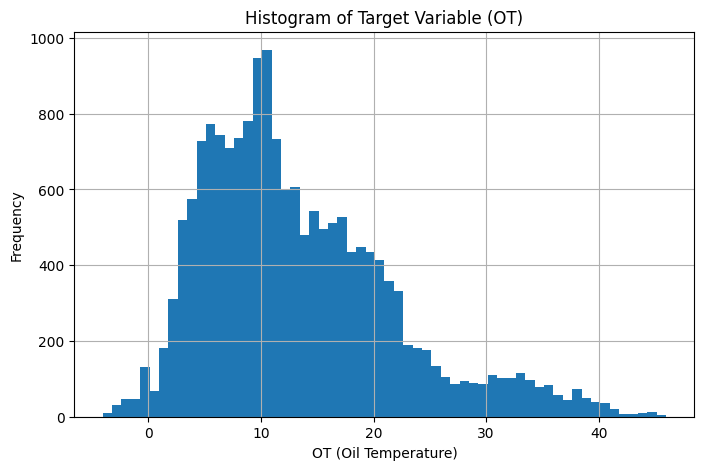

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df["OT"], bins=60)
plt.title("Histogram of Target Variable (OT)")
plt.xlabel("OT (Oil Temperature)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Biểu đồ tương quan

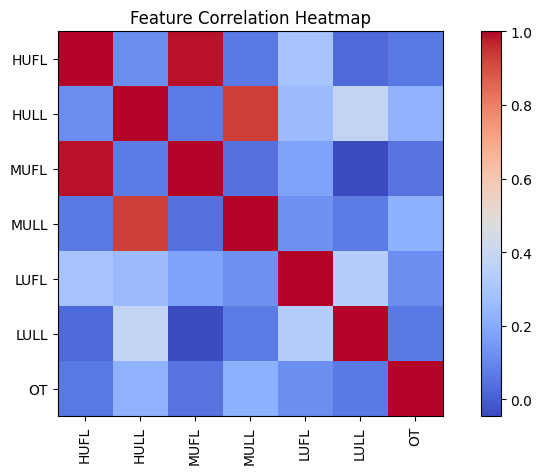

In [49]:
correlation = df.corr()
plt.figure(figsize=(10,5))
plt.imshow(correlation,cmap = 'coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns.tolist())), df.columns.tolist(), rotation=90)
plt.yticks(range(len(df.columns.tolist())), df.columns.tolist())

plt.title("Feature Correlation Heatmap")
plt.show()

In [50]:
# Drop cột MUFL MULL
df.drop(labels=['MUFL','MULL'],axis=1,inplace=True)

In [51]:
df.iloc[120:]

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-06 00:00:00,10.382,5.090,3.015,1.828,28.913000
2016-07-06 01:00:00,10.717,5.425,2.833,1.919,30.389999
2016-07-06 02:00:00,10.851,5.358,2.833,1.858,31.514999
2016-07-06 03:00:00,9.779,5.157,3.168,2.132,31.233999
2016-07-06 04:00:00,9.377,4.488,3.015,2.041,30.531000
...,...,...,...,...,...
2018-06-26 15:00:00,-1.674,3.550,3.472,1.523,10.904000
2018-06-26 16:00:00,-5.492,4.287,3.533,1.675,11.044000
2018-06-26 17:00:00,2.813,3.818,3.716,1.523,10.271000


### Data augment

In [52]:
stl = STL(df["OT"], period=24)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid

df["trend"] = trend # Xu huong train
df["seasonal"] = seasonal # Chu ky
df["residual"] = residual # Nhieu


In [53]:
df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383


### Kiểm tra toàn bộ pha đã tắt nhưng OT > 0


In [54]:
load_cols = ['HUFL','HULL','LUFL','LULL']
mask_shutdown = (df[load_cols] == 0).all(axis=1)
df[mask_shutdown].head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-12-05 09:00:00,0.0,0.0,0.0,0.0,15.336,12.222183,0.101522,3.012295
2016-12-05 10:00:00,0.0,0.0,0.0,0.0,12.874,11.646167,0.080922,1.146911
2016-12-05 11:00:00,0.0,0.0,0.0,0.0,12.451,11.042708,0.661888,0.746404
2016-12-05 12:00:00,0.0,0.0,0.0,0.0,10.482,10.415267,0.299863,-0.233130
2016-12-05 13:00:00,0.0,0.0,0.0,0.0,11.889,9.768518,1.559895,0.560587


In [55]:
# Thêm cột trạng thái
df['is_shutdown'] = mask_shutdown.astype(int)


In [56]:
df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,is_shutdown
date,,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763,0
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092,0
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112,0
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792,0
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383,0


In [57]:
df[mask_shutdown].head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,is_shutdown
date,,,,,,,,,
2016-12-05 09:00:00,0.0,0.0,0.0,0.0,15.336,12.222183,0.101522,3.012295,1
2016-12-05 10:00:00,0.0,0.0,0.0,0.0,12.874,11.646167,0.080922,1.146911,1
2016-12-05 11:00:00,0.0,0.0,0.0,0.0,12.451,11.042708,0.661888,0.746404,1
2016-12-05 12:00:00,0.0,0.0,0.0,0.0,10.482,10.415267,0.299863,-0.233130,1
2016-12-05 13:00:00,0.0,0.0,0.0,0.0,11.889,9.768518,1.559895,0.560587,1


### Signal plot

plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(df["OT"])
plt.title("Original")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonal")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()
plt.show()

In [58]:
train_df = df.iloc[:train_size]
val_df   = df.iloc[train_size:train_size+val_size]
test_df  = df.iloc[train_size+val_size:]

In [59]:
train_df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,is_shutdown
date,,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763,0
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092,0
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112,0
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792,0
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383,0


### Timer Frezee

In [60]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,is_shutdown
date,,,,,,,,,
2017-03-31 02:00:00,10.248,0.0,4.264,1.279,6.753,5.903357,0.703572,0.146071,0
2017-03-31 03:00:00,10.248,0.0,4.264,1.279,6.753,5.933898,0.464941,0.354161,0
2017-03-31 04:00:00,10.248,0.0,4.264,1.279,6.753,5.982864,0.609077,0.161059,0
2017-03-31 05:00:00,10.248,0.0,4.264,1.279,6.753,6.051070,0.388829,0.313101,0
2017-03-31 06:00:00,10.248,0.0,4.264,1.279,6.753,6.138688,-0.464606,1.078918,0
2017-03-31 07:00:00,10.248,0.0,4.264,1.279,6.753,6.245068,-0.438963,0.946895,0
2017-03-31 08:00:00,10.248,0.0,4.264,1.279,6.753,6.368775,-0.406277,0.790502,0
2017-03-31 09:00:00,10.248,0.0,4.264,1.279,6.753,6.507604,-0.168325,0.413721,0
2017-03-31 10:00:00,10.248,0.0,4.264,1.279,6.753,6.659053,-0.483829,0.577776,0


In [61]:
# tổng thay đổi mỗi dòng
diff_sum_train = train_df.diff().abs().sum(axis=1)
diff_sum_val = val_df.diff().abs().sum(axis=1)
diff_sum_test = test_df.diff().abs().sum(axis=1)

# dòng không thay đổi
is_constant_train = diff_sum_train == 0
is_constant_val = diff_sum_val == 0
is_constant_test = diff_sum_test == 0

# phát hiện block >= 6 giờ
window = 6
freeze_block_train = is_constant_train.rolling(window).sum() >= window
freeze_block_val = is_constant_val.rolling(window).sum() >= window
freeze_block_test = is_constant_test.rolling(window).sum() >= window

train_df.loc[freeze_block_train] = np.nan
val_df.loc[freeze_block_val] = np.nan
test_df.loc[freeze_block_test] = np.nan

train_df.interpolate(method="time", inplace=True)
val_df.interpolate(method="time", inplace=True)
test_df.interpolate(method="time", inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\265151042.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.interpolate(method="time", inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\265151042.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.interpolate(method="time", inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\265151042.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_

In [62]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,is_shutdown
date,,,,,,,,,
2017-03-31 02:00:00,10.248,0.0,4.264,1.279,6.753,5.903357,0.703572,0.146071,0
2017-03-31 03:00:00,10.248,0.0,4.264,1.279,6.753,5.933898,0.464941,0.354161,0
2017-03-31 04:00:00,10.248,0.0,4.264,1.279,6.753,5.982864,0.609077,0.161059,0
2017-03-31 05:00:00,10.248,0.0,4.264,1.279,6.753,6.051070,0.388829,0.313101,0
2017-03-31 06:00:00,10.248,0.0,4.264,1.279,6.753,6.138688,-0.464606,1.078918,0
2017-03-31 07:00:00,10.248,0.0,4.264,1.279,6.753,6.245068,-0.438963,0.946895,0
2017-03-31 08:00:00,10.248,0.0,4.264,1.279,6.753,6.368775,-0.406277,0.790502,0
2017-03-31 09:00:00,10.248,0.0,4.264,1.279,6.753,6.507604,-0.168325,0.413721,0
2017-03-31 10:00:00,10.248,0.0,4.264,1.279,6.753,6.659053,-0.483829,0.577776,0


### Data Augment

In [63]:
#Train
train_df["hour_sin"] = np.sin(2*np.pi*train_df.index.hour/24)
train_df["hour_cos"] = np.cos(2*np.pi*train_df.index.hour/24)

#Val
val_df["hour_sin"] = np.sin(2*np.pi*val_df.index.hour/24)
val_df["hour_cos"] = np.cos(2*np.pi*val_df.index.hour/24)

#Test
test_df["hour_sin"] = np.sin(2*np.pi*test_df.index.hour/24)
test_df["hour_cos"] = np.cos(2*np.pi*test_df.index.hour/24)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\2883704054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["hour_sin"] = np.sin(2*np.pi*train_df.index.hour/24)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\2883704054.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["hour_cos"] = np.cos(2*np.pi*train_df.index.hour/24)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\2883704054.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [64]:
df.head(10)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,is_shutdown
date,,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763,0
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092,0
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112,0
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792,0
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383,0
2016-07-01 05:00:00,5.626,2.143,4.051,1.371,21.174000,20.602776,0.394933,0.176291,0
2016-07-01 06:00:00,7.167,2.947,5.026,1.858,22.792000,20.592306,0.637097,1.562597,0
2016-07-01 07:00:00,7.435,3.282,5.087,2.224,23.143999,20.581745,1.009967,1.552287,0
2016-07-01 08:00:00,5.559,3.014,2.955,1.432,21.667000,20.570925,0.370598,0.725478,0


### Thống kê phân phối theo tập trước khi scale

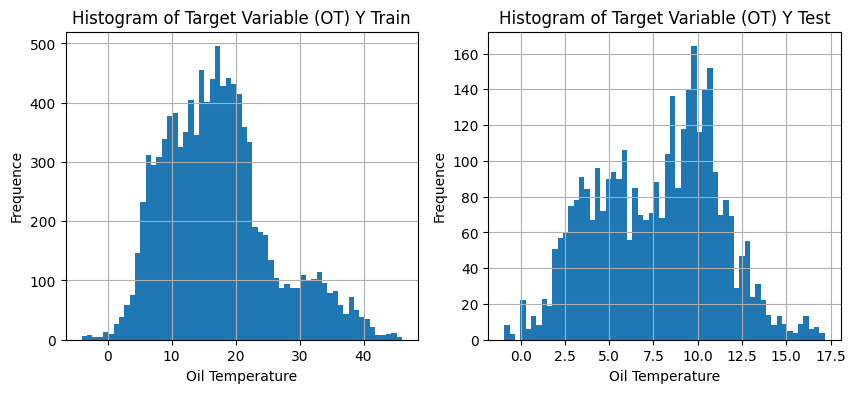

In [65]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([train_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Train')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.subplot(1,2,2)
plt.hist([test_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Test')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.show()

In [66]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

### Inverst Function

In [67]:
def inverst(x,scaler,target_index):
    return x * scaler.scale_[target_index] + scaler.mean_[target_index]

In [68]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, target_index):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_index = target_index

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len, self.target_index]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [69]:

target_index = df.columns.get_loc(target_col)
print(target_index)
train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len, target_index)
val_dataset   = TimeSeriesDataset(val_scaled, seq_len, pred_len, target_index)
test_dataset  = TimeSeriesDataset(test_scaled, seq_len, pred_len, target_index)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

4


### Thống kê phân phối dữ liệu sau khi scale

In [70]:
y_train_all = []
y_test_all = []

for i in range(len(train_dataset)):
    _, y = train_dataset[i]
    y_train_all.append(y.numpy())

for i in range(len(test_dataset)):
    _, y = test_dataset[i]
    y_test_all.append(y.numpy())

y_train_all = np.concatenate(y_train_all)
y_test_all = np.concatenate(y_test_all)

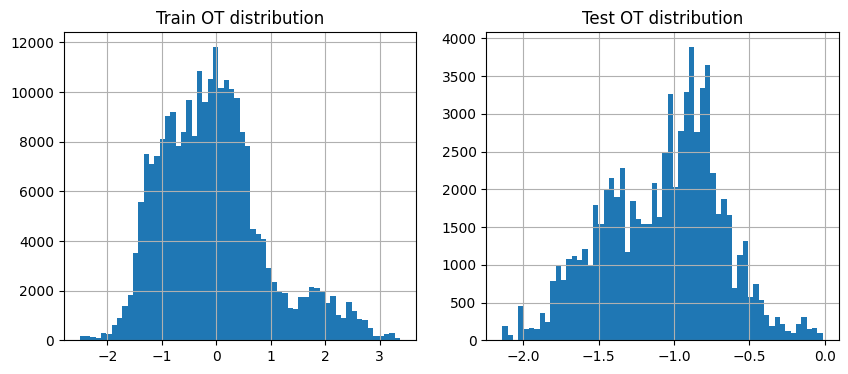

In [71]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(y_train_all, bins=60)
plt.title("Train OT distribution")
plt.grid(True)
plt.subplot(1,2,2)
plt.hist(y_test_all, bins=60)
plt.title("Test OT distribution")
plt.grid(True)
plt.show()

In [72]:
import torch
import torch.nn as nn
import random


class Seq2SeqLSTM(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_size=128,
        num_layers=2,
        pred_len=24,
        drop_out=0.3,
        teacher_forcing_ratio=0.5,
        target_idx=4
    ):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.pred_len = pred_len
        self.teacher_forcing_ratio = teacher_forcing_ratio
        self.target_idx = target_idx

        # ===== Encoder =====
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=drop_out,
            batch_first=True,
            bidirectional=True
        )

        # ===== Decoder (input_size = 1 để khớp checkpoint) =====
        self.decoder = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size * 2,
            num_layers=num_layers,
            dropout=drop_out,
            batch_first=True
        )

        # ===== Output head =====
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x, y=None):

        batch_size = x.size(0)

        # ================= Encoder =================
        _, (hidden, cell) = self.encoder(x)

        # reshape hidden cho bidirectional
        hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
        cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)

        # concat forward + backward
        hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)
        cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)

        # ================= Decoder input đầu tiên =================
        decoder_input = x[:, -1:, self.target_idx:self.target_idx+1]

        outputs = []

        # ================= Decoder =================
        for t in range(self.pred_len):

            out, (hidden, cell) = self.decoder(
                decoder_input,
                (hidden, cell)
            )

            out = out.squeeze(1)

            pred = self.fc(out)   # (batch,1)

            outputs.append(pred.unsqueeze(1))

            # ===== teacher forcing =====
            if self.training and y is not None and random.random() < self.teacher_forcing_ratio:
                decoder_input = y[:, t].unsqueeze(1).unsqueeze(2)
            else:
                decoder_input = pred.unsqueeze(1)

        outputs = torch.cat(outputs, dim=1)

        return outputs.squeeze(-1)

In [73]:
print(train_scaled.shape)

(10452, 11)


In [74]:
model = Seq2SeqLSTM(
    input_dim = train_scaled.shape[1],
    pred_len = pred_len
).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)


In [75]:
history = []
best_val_loss = float('inf')
train_loss = float('inf')
best_epoch = 0
patience = 5
counter = 0
for epoch in range(epochs):

    model.train()
    total_train_loss = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = model(X_batch)
        loss = criterion(output, y_batch)

        loss.backward() # Backpropagation Through Time
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

        optimizer.step() # Gradient Descent update

        y_pred_inverst = inverst(output.detach().cpu().numpy(),scaler,target_index)
        y_true_inverst = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)

        train_loss = mse_loss(y_pred_inverst,y_true_inverst)
        total_train_loss.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    total_val_loss = []

    with torch.no_grad():
        for X_val_batch,y_val_batch in val_loader:
            X_val_batch = X_val_batch.to(device)
            y_val_batch = y_val_batch.to(device)
            output = model(X_val_batch)
            loss = criterion(output, y_val_batch)
            
            y_pred_inverst = inverst(output.detach().cpu().numpy(),scaler,target_index)
            y_true_inverst = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
            loss_real = mse_loss(y_pred_inverst,y_true_inverst)
            total_val_loss.append(loss_real)
    total_train_loss = np.average(total_train_loss)
    total_val_loss = np.average(total_val_loss)
    scheduler_reduce.step(total_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {total_train_loss:.4f} | "
        f"Val Loss: {total_val_loss:.4f} |" 
        f"LR: {current_lr:.6f}"
    )
    # ===== SAVE BEST MODEL =====
    if total_val_loss < best_val_loss:
        train_loss = total_train_loss
        best_val_loss = total_val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': total_val_loss,
            'train_loss': total_train_loss,
            'lr':lr,
            'drop_out':drop_out,
            'seq_len':seq_len,
            'pred_len':pred_len
        }, "checkpoint.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break
    history.append((total_train_loss,total_val_loss))

Epoch 01 | Train Loss: 29.7717 | Val Loss: 5.6443 |LR: 0.000100
Epoch 02 | Train Loss: 6.0951 | Val Loss: 5.3451 |LR: 0.000100
Epoch 03 | Train Loss: 5.2868 | Val Loss: 2.6033 |LR: 0.000100
Epoch 04 | Train Loss: 4.4566 | Val Loss: 2.0562 |LR: 0.000100
Epoch 05 | Train Loss: 4.0837 | Val Loss: 3.0629 |LR: 0.000100
Epoch 06 | Train Loss: 3.7295 | Val Loss: 1.9398 |LR: 0.000100
Epoch 07 | Train Loss: 3.4919 | Val Loss: 3.3623 |LR: 0.000100
Epoch 08 | Train Loss: 3.3067 | Val Loss: 2.4062 |LR: 0.000100
Epoch 09 | Train Loss: 3.2027 | Val Loss: 3.2142 |LR: 0.000100
Epoch 10 | Train Loss: 3.0210 | Val Loss: 4.0523 |LR: 0.000050
Epoch 11 | Train Loss: 2.8948 | Val Loss: 2.3374 |LR: 0.000050
Early stopping


In [76]:
print(f'Best Epoch:{best_epoch}')
print(f'Best Train Loss: {train_loss}')
print(f'Best Val Loss: {best_val_loss}')

Best Epoch:6
Best Train Loss: 2.7948589311120395
Best Val Loss: 1.9398269470961176


In [77]:
checkpoint = torch.load("checkpoint.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
total_loss=  []
preds = []
trues = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        output = model(x)
        loss = criterion(output,y)

        total_loss.append(loss.item())
        preds.append(output.cpu().numpy())
        trues.append(y.cpu().numpy())
    total_loss = np.average(total_loss)
print(f'Loss: {total_loss}')
preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)



C:\Users\Admin\AppData\Local\Temp\ipykernel_2588\1169781181.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoint.pth", map_location=device

Loss: 0.025471315377068763


In [78]:
print(preds.shape)
print(trues.shape)

(3125, 24)
(3125, 24)


preds_flat = preds.reshape(-1,1)
trues_flat = trues.reshape(-1,1)

dummy_pred = np.zeros((preds_flat.shape[0], train_scaled.shape[1]))
dummy_true = np.zeros((trues_flat.shape[0], train_scaled.shape[1]))

dummy_pred[:, target_index] = preds_flat[:,0]
dummy_true[:, target_index] = trues_flat[:,0]

inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [79]:

# tạo mảng giả để inverse
dummy_pred = np.zeros((preds.shape[1], train_scaled.shape[1]))
dummy_true = np.zeros((trues.shape[1], train_scaled.shape[1]))

dummy_pred[:, target_index] = preds[0]
dummy_true[:, target_index] = trues[0]

inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [80]:
print(f'Prediction: {inv_pred}')
print(f'True: {inv_true}')
print(f'Real Loss: {MSE_Real}')

Prediction: [3.9587305  3.48075151 3.28425621 3.22362256 3.22594569 3.25911085
 3.30891542 3.36811805 3.4335177  3.50345906 3.57662681 3.65256527
 3.73031736 3.80968011 3.89002327 3.9709236  4.05215886 4.13336266
 4.21406712 4.29424484 4.37385219 4.45238272 4.5301277  4.60687098]
True: [3.6580001  3.23600038 2.6030003  2.53200039 3.02500002 3.23600038
 3.44699973 3.30599959 3.02500002 3.44699973 3.30599959 3.6580001
 3.44699973 3.30599959 3.79900024 4.15000004 3.09500024 3.51699996
 3.37700052 4.43200032 5.13500063 5.41699989 5.69799947 5.69799947]
Real Loss: 0.32726346762757846


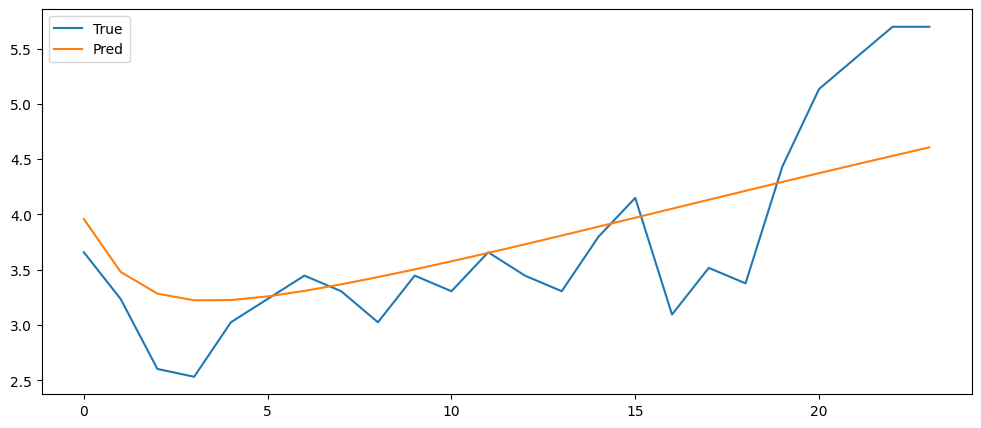

In [81]:
plt.figure(figsize=(12,5))
plt.plot(inv_true[:], label="True")
plt.plot(inv_pred[:], label="Pred")
plt.legend()
plt.show()

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_list = []
rmse_list = []
mse_list = []
for h in range(pred_len):
    trues_inv = inverst(trues[:,h],scaler,target_index)
    preds_inv = inverst(preds[:,h],scaler,target_index)
    mae = mean_absolute_error(trues_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(trues_inv, preds_inv))
    mse = mean_squared_error(trues_inv, preds_inv)
    mae_list.append(mae)
    rmse_list.append(rmse)
    mse_list.append(mse)

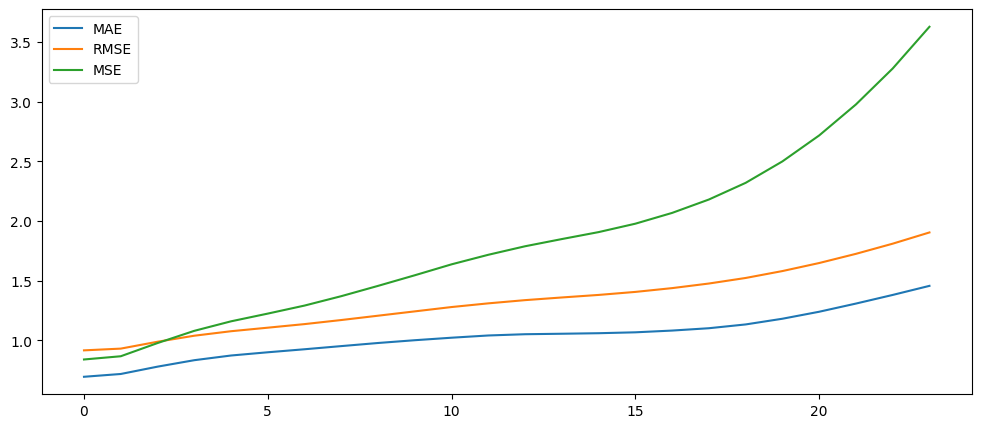

In [83]:
plt.figure(figsize=(12,5))
plt.plot(mae_list, label="MAE")
plt.plot(rmse_list, label="RMSE")
plt.plot(mse_list,label='MSE')
plt.legend()
plt.show()

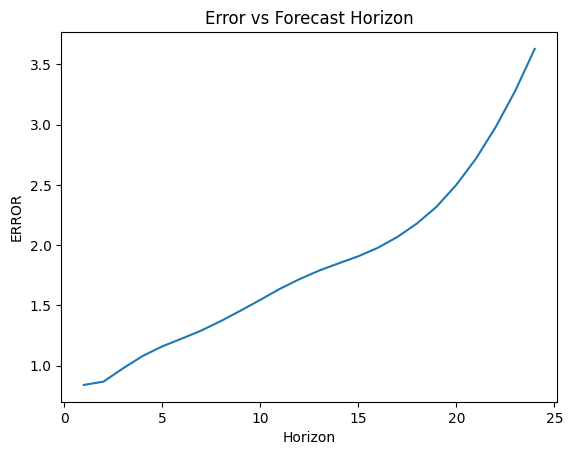

In [84]:
plt.plot(range(1,pred_len+1), mse_list)
plt.xlabel("Horizon")
plt.ylabel("ERROR")
plt.title("Error vs Forecast Horizon")
plt.show()